# Correction - Prédiction des notes d'étudiants

## Partie 1 - Préparation des données
### Étape 1.1 : Chargement et exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

np.random.seed(42)
n = 500

df = pd.DataFrame({
    'age':              np.random.randint(15, 23, n),
    'study_time':       np.random.randint(1, 5, n),
    'failures':         np.random.choice([0, 1, 2, 3], n, p=[0.6, 0.25, 0.1, 0.05]),
    'absences':         np.random.randint(0, 40, n),
    'parental_support': np.random.choice(['none','low','medium','high','very high'], n),
    'extracurricular':  np.random.choice(['yes', 'no'], n),
    'internet':         np.random.choice(['yes', 'no'], n, p=[0.7, 0.3]),
    'health':           np.random.randint(1, 6, n),
    'freetime':         np.random.randint(1, 6, n),
    'goout':            np.random.randint(1, 6, n),
})

df['passed'] = (
    (df['study_time'] >= 3) * 0.4 +
    (df['failures'] == 0) * 0.3 +
    (df['absences'] < 10) * 0.2 +
    (df['parental_support'].isin(['high', 'very high'])) * 0.1 +
    np.random.uniform(0, 0.3, n)
) > 0.5
df['passed'] = df['passed'].astype(int)

print(df.head())
print(f"\nDimensions : {df.shape}")
print(f"Taux de réussite : {df['passed'].mean():.1%}")

   age  study_time  failures  absences parental_support extracurricular  \
0   21           3         1        11        very high              no   
1   18           1         0        15              low              no   
2   19           1         0        23             high              no   
3   21           4         1        18             none              no   
4   17           3         1         7             none              no   

  internet  health  freetime  goout  passed  
0      yes       3         4      4       1  
1      yes       2         3      4       0  
2      yes       2         4      3       1  
3      yes       1         1      2       1  
4       no       3         5      3       1  

Dimensions : (500, 11)
Taux de réussite : 67.0%


### Étape 1.2 : Prétraitement

In [2]:
X = df.drop('passed', axis=1)
y = df['passed']

numeric_features = ['age', 'study_time', 'failures', 'absences', 'health', 'freetime', 'goout']
categorical_features = [ 'extracurricular', 'internet']
ordinal_feature = ['parental_support']

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[['none','low','medium','high','very high']]))
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features),
    ('ord', ordinal_pipeline, ordinal_feature)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Partie 2 - Entraînement du modèle
### Étape 2.1 : Random Forest

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Pipeline complet
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

rf_pipeline.fit(X_train, y_train)

y_pred = rf_pipeline.predict(X_test)
print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
print(classification_report(y_test, y_pred))

Accuracy : 0.830
              precision    recall  f1-score   support

           0       0.84      0.62      0.71        34
           1       0.83      0.94      0.88        66

    accuracy                           0.83       100
   macro avg       0.83      0.78      0.80       100
weighted avg       0.83      0.83      0.82       100



## Partie 3 - Feature Importance
### Étape 3.1 : Extraction des importances

In [4]:
rf_clf = rf_pipeline.named_steps['classifier']
preprocessor_fitted = rf_pipeline.named_steps['preprocessor']

ohe = preprocessor_fitted.named_transformers_['cat'].named_steps['onehot']
cat_feature_names = ohe.get_feature_names_out(categorical_features).tolist()
all_feature_names = numeric_features + cat_feature_names + ordinal_feature

importances = rf_clf.feature_importances_
feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=False)
print(feat_imp)

study_time             0.319059
failures               0.150838
absences               0.144460
parental_support       0.075552
age                    0.071874
goout                  0.064727
freetime               0.059876
health                 0.054320
extracurricular_yes    0.016274
extracurricular_no     0.015233
internet_no            0.014532
internet_yes           0.013253
dtype: float64


### Étape 3.2 : Visualisation des importances

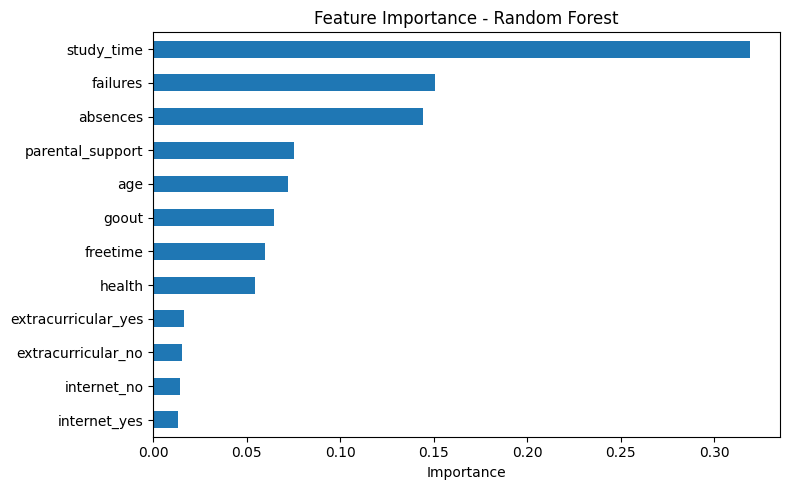

In [5]:
plt.figure(figsize=(8, 5))
feat_imp.plot(kind='barh')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Étape 3.3 : Comparaison Decision Tree vs Random Forest

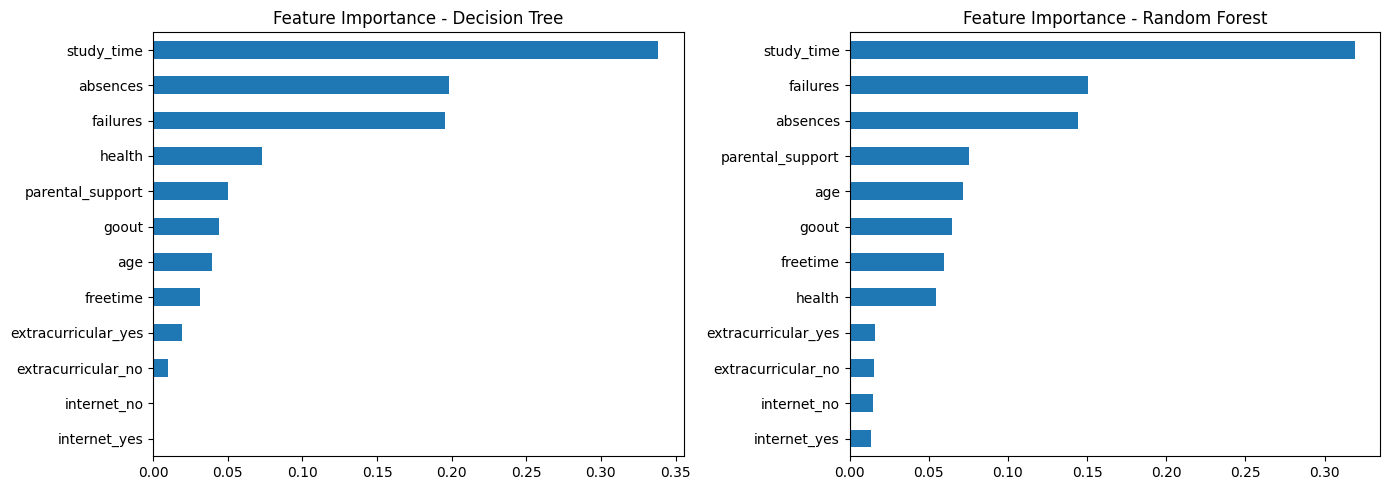

In [6]:
from sklearn.tree import DecisionTreeClassifier

dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

dt_pipeline.fit(X_train, y_train)
dt_clf = dt_pipeline.named_steps['classifier']

dt_imp = pd.Series(dt_clf.feature_importances_, index=all_feature_names).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dt_imp.plot(kind='barh', ax=axes[0])
axes[0].set_title('Feature Importance - Decision Tree')
axes[0].invert_yaxis()

feat_imp.plot(kind='barh', ax=axes[1])
axes[1].set_title('Feature Importance - Random Forest')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## Partie 4 - Analyse SHAP
### Étape 4.1 : Calcul des valeurs SHAP

In [7]:
import shap

X_train_transformed = preprocessor_fitted.transform(X_train)
X_test_transformed = preprocessor_fitted.transform(X_test)

rf_shap = RandomForestClassifier(n_estimators=100, random_state=42)
rf_shap.fit(X_train_transformed, y_train)

explainer = shap.TreeExplainer(rf_shap)
shap_values_raw = explainer.shap_values(X_test_transformed)

shap_values = [shap_values_raw[:, :, i] for i in range(shap_values_raw.shape[2])]


print(f"Shape des valeurs SHAP (classe 1) : {shap_values[1].shape}")

c:\Users\Administrateur\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Shape des valeurs SHAP (classe 1) : (100, 12)


### Étape 4.2 : Summary Plot

C:\Users\Administrateur\AppData\Local\Temp\ipykernel_1144\2022747387.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[1], X_test_transformed, feature_names=all_feature_names)


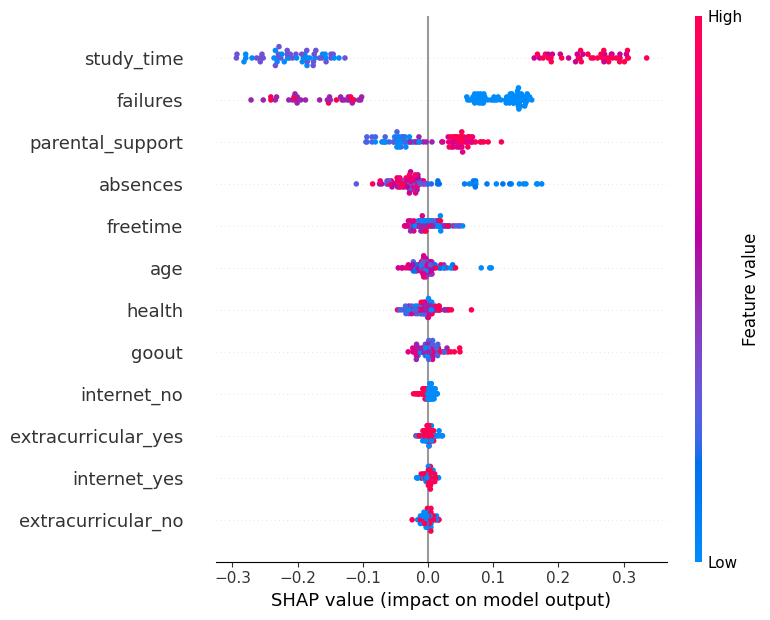

In [8]:
shap.summary_plot(shap_values[1], X_test_transformed, feature_names=all_feature_names)

### Étape 4.3 : Waterfall Plot (explication locale)

Caractéristiques de l'élève :
age                        18
study_time                  3
failures                    2
absences                   29
parental_support    very high
extracurricular            no
internet                  yes
health                      4
freetime                    4
goout                       3
Name: 68, dtype: object

Réussi : 1


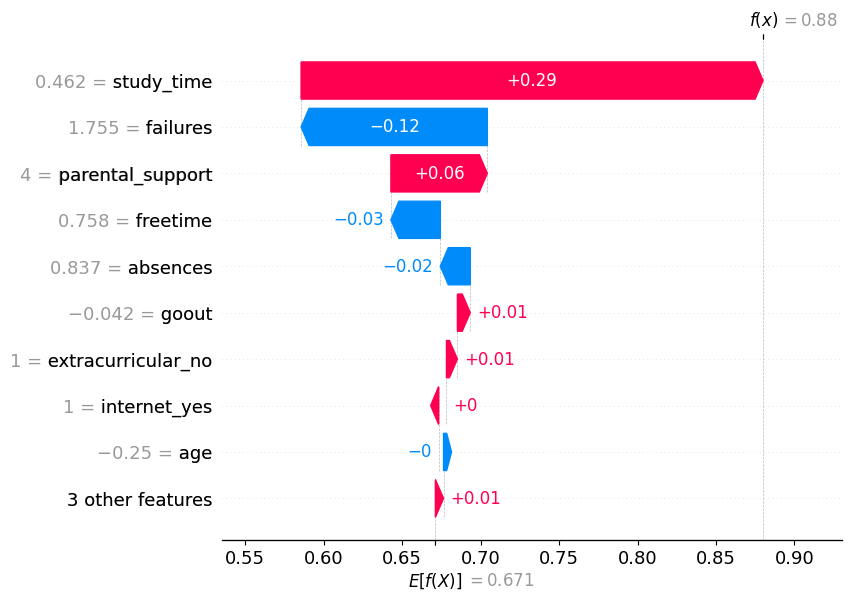

In [9]:
sample_idx = 8

print("Caractéristiques de l'élève :")
print(X_test.iloc[sample_idx])
print(f"\nRéussi : {y_test.iloc[sample_idx]}")

shap_exp = shap.Explanation(
    values=shap_values[1][sample_idx],
    base_values=explainer.expected_value[1],
    data=X_test_transformed[sample_idx],
    feature_names=all_feature_names
)
shap.waterfall_plot(shap_exp)

### Étape 4.4 (Bonus) : Comparer deux élèves

Réussite


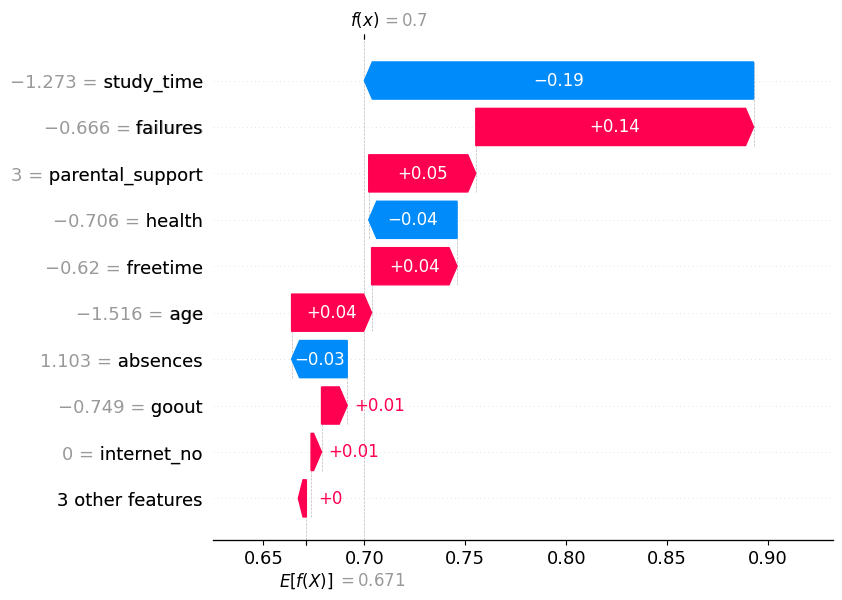

Echec


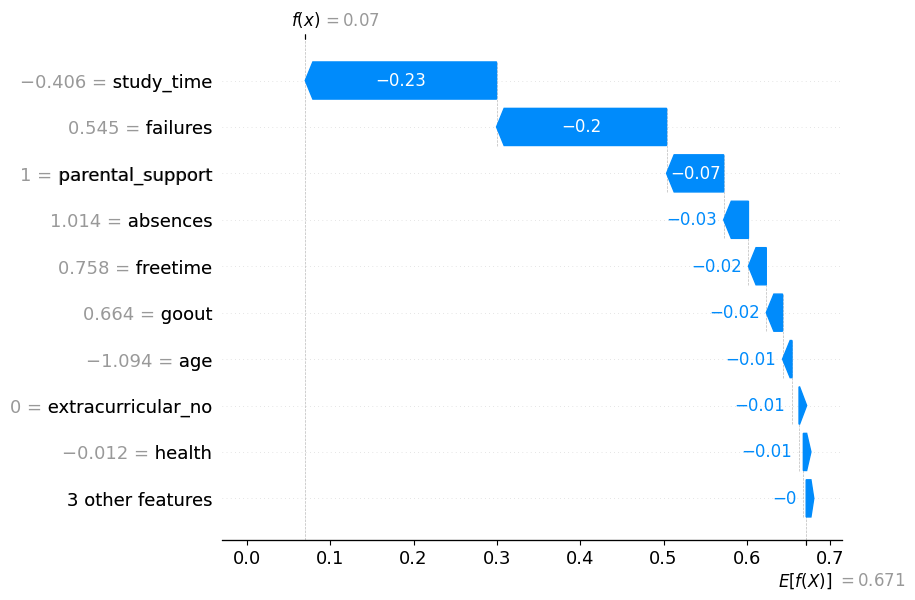

In [10]:
y_test_reset = y_test.reset_index(drop=True)
idx_passed = y_test_reset[y_test_reset == 1].index[0]
idx_failed = y_test_reset[y_test_reset == 0].index[0]

# Élève ayant réussi
print("Réussite")
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[1][idx_passed],
        base_values=explainer.expected_value[1],
        data=X_test_transformed[idx_passed],
        feature_names=all_feature_names
    )
)

# Élève ayant échoué
print("Echec")
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[1][idx_failed],
        base_values=explainer.expected_value[1],
        data=X_test_transformed[idx_failed],
        feature_names=all_feature_names
    )
)